In [2]:
import imageio
import matplotlib.pyplot as plot
import matplotlib.patches as mpatches
import scipy.ndimage as ndi
import numpy as np

from module.preprocessing import *

from skimage import exposure, filters, morphology, measure, color, img_as_float, feature, transform, draw, metrics

/tmp/ipykernel_6466/3323083133.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread("../dataset/Assigment1/Ultrasound Fetus Dataset/validation/normal/243_HC.png")


(545, 784) uint8


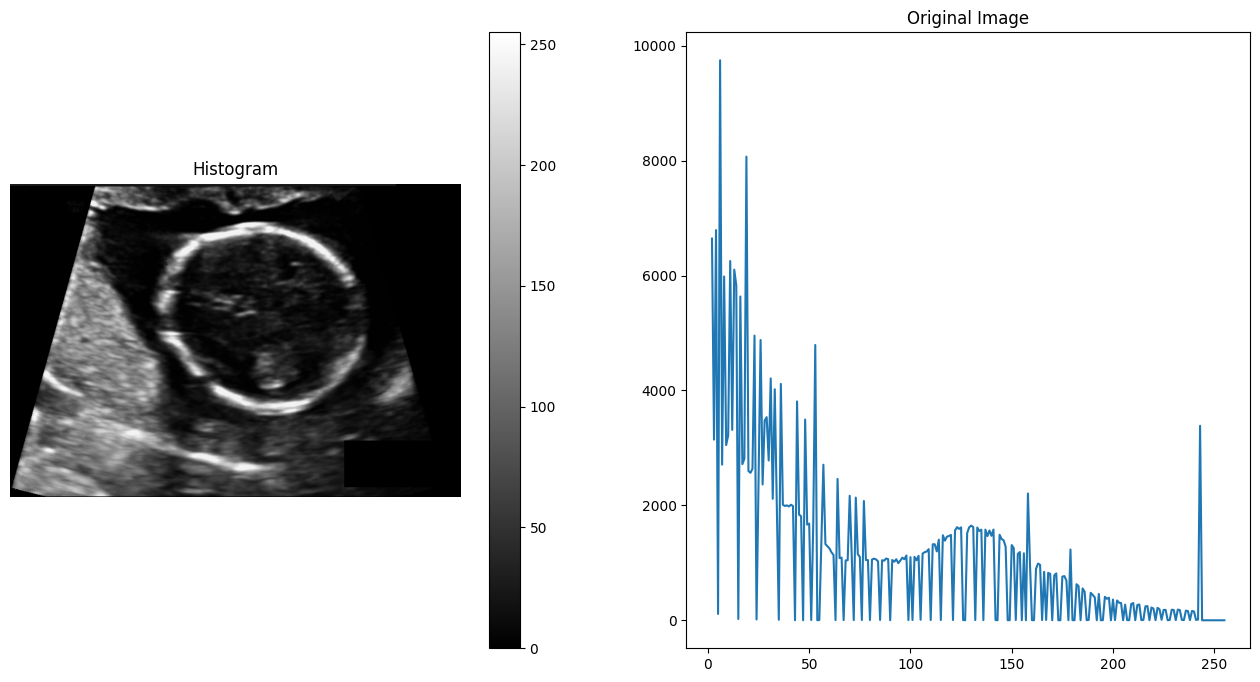

In [3]:
# im = imageio.imread("../dataset/Assigment1/Ultrasound Fetus Dataset/validation/normal/165_HC.png")
# im = imageio.imread("../dataset/Assigment1/Ultrasound Fetus Dataset/validation/normal/128_HC.png")
im = imageio.imread("../dataset/Assigment1/Ultrasound Fetus Dataset/validation/normal/243_HC.png")

hist = ndi.histogram(im, 0, 255, 256)
x = np.arange(2, len(hist))

print(im.shape, im.dtype)
fig, ax = plt.subplots(1, 2, figsize=(16, 8))

im_display = ax[0].imshow(im, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Histogram')
ax[0].axis('off')

ax[1].plot(x, hist[2:])
ax[1].set_title('Original Image')

fig.colorbar(im_display, ax=ax[0])

plt.show()

int64 (256,)


<function matplotlib.pyplot.show(close=None, block=None)>

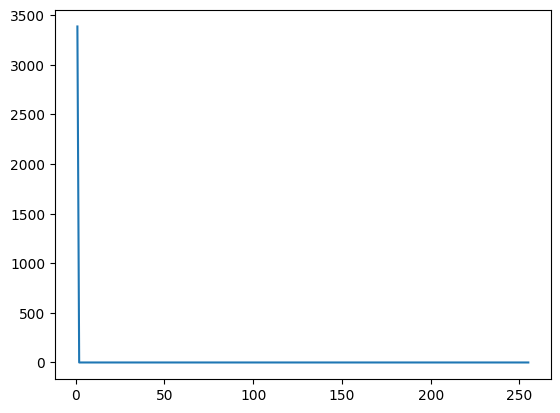

In [4]:
eq_hist = exposure.equalize_hist(im)
hist = ndi.histogram(eq_hist, 0, 255, 256)
x = np.arange(1, len(hist))
print(hist.dtype, hist.shape)

# plot.imshow(eq_hist, cmap="gray")
plot.plot(x, hist[1:])
plot.show

gauss PSNR: 30.57625488254551
MSE: 508.91839309118143
Median PSNR: 41.894411352072865
MSE: 11.908696873244711


(-0.5, 783.5, 544.5, -0.5)

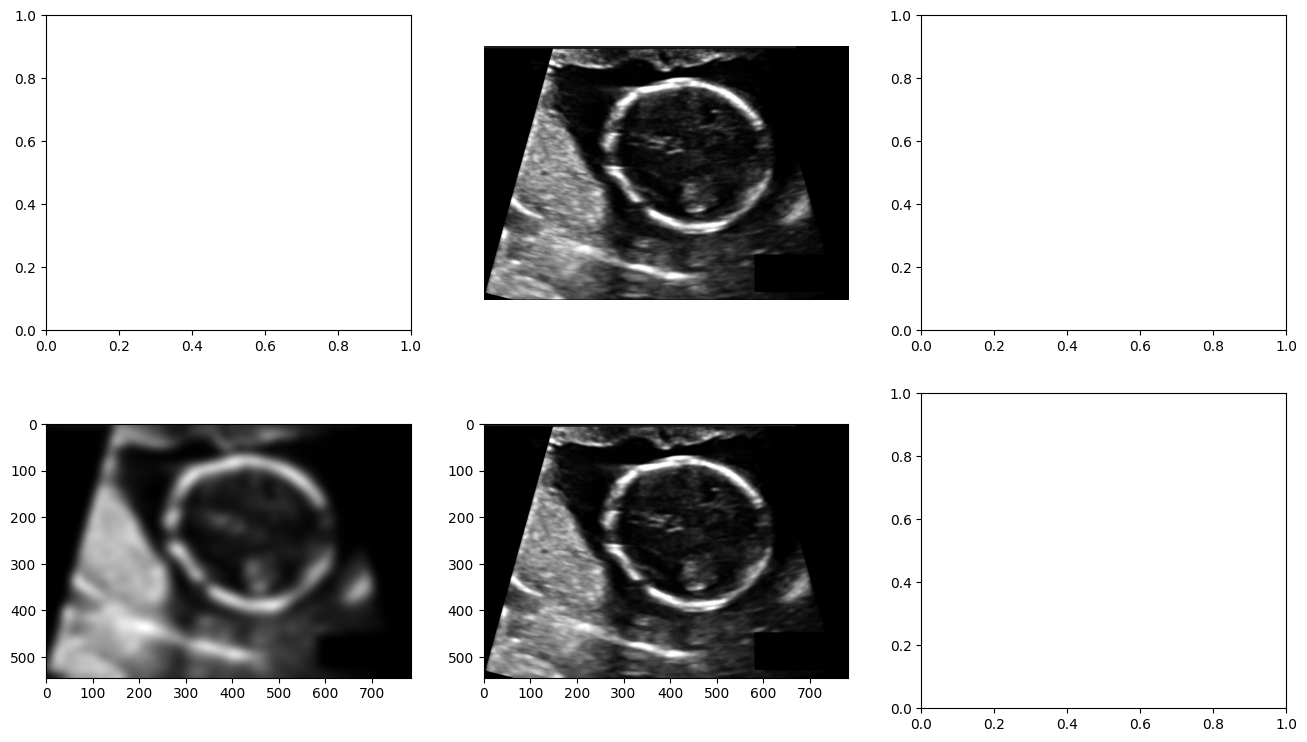

In [5]:
# searching for optimal enchancement
fig, ax = plot.subplots(2, 3, figsize=(16,9))
ax[0,1].imshow(im, cmap="gray"); ax[0,1].axis("off")

im_gaussian = ndi.gaussian_filter(im, sigma=10)
AnalysisPreROI("gauss", im, im_gaussian)

im_median = ndi.median_filter(im, size=(5,5))
AnalysisPreROI("Median", im, im_median)

ax[1,0].imshow(im_gaussian, cmap="gray"); ax[0,1].axis("off")
ax[1,1].imshow(im_median, cmap="gray"); ax[0,1].axis("off")



<function matplotlib.pyplot.show(close=None, block=None)>

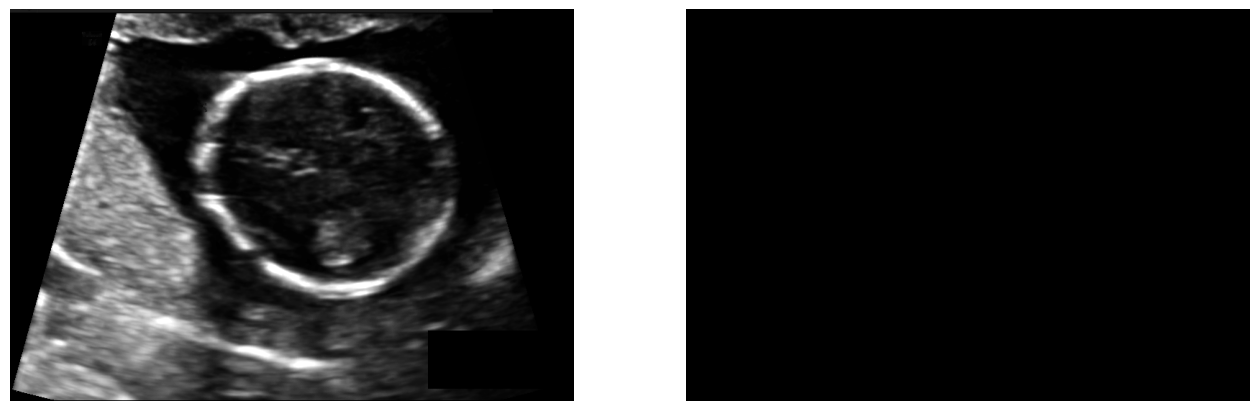

In [ ]:
im_filt = ndi.median_filter(im, size=(3,3))

outside = filters.threshold_otsu(im)
inner = im > outside 
inner = morphology.remove_small_objects(inner, 2100)
inner = ndi.binary_fill_holes(inner)

head = morphology.binary_opening(inner, morphology.disk(5))
head = morphology.dilation(head, morphology.square(13))

label = measure.label(head)
bg = label.max()

# head = head  bg

fig, ax = plot.subplots(1, 2, figsize=(16,8))
ax[0].imshow(im, cmap="gray")
ax[0].axis('off')

ax[1].imshow(head, cmap="gray")
ax[1].axis('off')

plot.show